In [1]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict, train_test_split
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
import torch
import torch.nn as nn
from torch.autograd import Variable
from torch.utils.data import Dataset, DataLoader

load_previously_saved_model = 0

In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cpu'

In [3]:
data = pd.read_csv('Titanic-Dataset.csv')

In [4]:
data.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [5]:
data.drop(columns = ['Name', 'PassengerId',  'Cabin','SibSp', 'Parch', 'Ticket', 'Pclass'], inplace = True)

categorical_features = ['Sex', 'Embarked', 'Survived']
numeric_features = [x for x in list(data.columns) if x not in categorical_features]
#numeric_features = ['latitude', 'longitude', 'price', 'minimum_nights']


data[numeric_features] = data[numeric_features].fillna(data[numeric_features].median())

data[categorical_features] = data[categorical_features].fillna(data[categorical_features].mode().iloc[0])
data = pd.get_dummies(data, columns = categorical_features, dtype=int)

sc = StandardScaler()
data[numeric_features] = sc.fit_transform(data[numeric_features])

y = data[['Survived_0', 'Survived_1']]
X = data.drop(columns = ['Survived_0', 'Survived_1'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

dataset_train = pd.concat([X_train, y_train], axis = 1)
#dataset_test = pd.concat([X_test, y_test], axis = 1)

In [6]:
y_test.head()

,Survived_0,Survived_1
709,0,1
439,1,0
840,1,0
720,0,1
39,0,1


In [24]:
def accuracy(outputs, labels):
    
    _, preds = torch.max(outputs, dim=1)
    y_test['Survived'] = labels.apply(lambda x: 0 if x['Survived_0'] == 1 else 1, axis=1)
    out = torch.tensor(y_test['Survived'].values)
       
    return preds, out

In [25]:
class LanguageModelDataLoader(DataLoader):
    def __init__(self, dataset, batch_size, columns, shuffle=True):
        
        self.data = dataset
        self.batch_size = batch_size
        self.cuda = False
        self.columns = columns

    def __iter__(self):
        # concatenate your articles and build into batches
        shuffled = np.random.permutation(self.data)
        #print(shuffled.shape, self.columns)
        shuffled = pd.DataFrame(shuffled, columns = self.columns)
        count = len(shuffled)
        num_batches = (count - 1)//self.batch_size
        number = num_batches * self.batch_size
        #print(shuffled, type(shuffled))
        y = np.array(shuffled[['Survived_0', 'Survived_1']])
        x = np.array(shuffled.drop(columns = ['Survived_0', 'Survived_1']))
        
        x = torch.from_numpy(x)
        y = torch.from_numpy(y)
        if self.cuda:
            x = x.cuda()
            y = y.cuda()
        
        start = 0
        while start < num_batches:
            # if (np.random.uniform() < 0.95):
            #     L = round(np.random.normal(70,5))
            # else:
            #     L = round(np.random.normal(35,5))
            L = self.batch_size
            x_out = x[start:start + L]
            y_out = y[start:start + L]
            start = start + L
            yield x_out,y_out 

In [26]:
class LanguageModel(nn.Module):
    def __init__(self, dropout = 0, batch_norm = 0):
        super(LanguageModel, self).__init__()
        # self.vocab_size = charcount
        # self.embedding = nn.Embedding(self.vocab_size,400)
        self.linear = nn.ModuleList()
        self.linear.append(nn.Linear(7,64))
        if batch_norm:
            self.linear.append(nn.BatchNorm1d(64))
        self.linear.append(nn.ReLU())
        self.linear.append(nn.Linear(64,32))
        if batch_norm:
            self.linear.append(nn.BatchNorm1d(32))
        self.linear.append(nn.ReLU())
        if dropout:
            self.linear.append(nn.Dropout(p = 0.3))
        self.linear.append(nn.Linear(32,2))
        
    def forward(self, out):
        for layers in self.linear:
            out = layers(out)
        return out

In [27]:
# Basic setup for early stopping criteria
patience = 10  # epochs to wait after no improvement
delta = 0.01  # minimum change in the monitored metric
best_val_loss = float("inf")  # best validation loss to compare against
no_improvement_count = 0  # count of epochs with no improvement

class EarlyStopping:
    def __init__(self, patience=5, delta=0, verbose=False):
        self.patience = patience
        self.delta = delta
        self.verbose = verbose
        self.best_loss = None
        self.no_improvement_count = 0
        self.stop_training = False
    
    def check_early_stop(self, val_loss):
        if self.best_loss is None or val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.no_improvement_count = 0
        else:
            self.no_improvement_count += 1
            if self.no_improvement_count >= self.patience:
                self.stop_training = True
                if self.verbose:
                    print("Stopping early as no improvement has been observed.")

In [28]:
class LanguageModelTrainer:
    def __init__(self, model, loader, X_test, y_test, max_epochs=1, run_id='exp'):
        # feel free to add any other parameters here
        self.model = model
        self.loader = loader
        self.predictions = []
        self.epochs = 0
        self.max_epochs = max_epochs
        self.run_id = run_id
        self.sigmoid = nn.Sigmoid()
        self.train_losses = []
        self.val_losses = []
        
        self.X_test = X_test
        self.y_test = torch.from_numpy(y_test.values)
        
        # TODO: Define your optimizer and criterion here
        self.optimizer = torch.optim.Adam(model.parameters(),lr=0.001, weight_decay=1e-6)
        self.criterion = nn.BCELoss().to(DEVICE)

    def train(self):
        self.model.train() # set to training mode
        epoch_loss = 0
        num_batches = 0
        for batch_num, (inputs, targets) in enumerate(self.loader):
            epoch_loss += self.train_batch(inputs, targets)
        epoch_loss = epoch_loss / (batch_num + 1)
        predictions = self.sigmoid(torch.from_numpy(TestLanguageModel.prediction(np.array(self.X_test), self.model)))
        #preds, score = accuracy(predictions, self.y_test)
        val_loss = self.criterion(predictions.to(torch.float32), self.y_test.to(torch.float32))
        self.epochs += 1
        if self.epochs % 25 == 0:
            print('[TRAIN]  Epoch [%d/%d]   Loss: %.4f [VALID LOSS] %.4f'
                      % (self.epochs, self.max_epochs, epoch_loss.item(), val_loss))
        self.train_losses.append(epoch_loss.item())
        self.val_losses.append(val_loss)
        return val_loss

    def train_batch(self, inputs, targets):
        inputs = inputs.to(DEVICE).long()
        targets = targets.to(torch.float32)
        outputs = self.model(inputs.to(torch.float32))
        outputs = self.sigmoid(outputs)
        #print((outputs[:,0]), (outputs[:,1]), targets)
        loss = self.criterion(outputs, targets)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        return loss

In [29]:
class TestLanguageModel:
    def prediction(inp, model):
        model.eval()
        inp = torch.from_numpy(inp)
        inp = inp.to(torch.float32)
        h = model(inp)
        #print(h.shape, h)
        return h.cpu().data.numpy()

In [30]:
#hyperparameters here

NUM_EPOCHS = 450
BATCH_SIZE = 64

In [31]:
model = LanguageModel(dropout = 1, batch_norm = 0)
loader = LanguageModelDataLoader(dataset=dataset_train, batch_size=BATCH_SIZE, columns = dataset_train.columns, shuffle=True)
trainer = LanguageModelTrainer(model=model, loader=loader, max_epochs=NUM_EPOCHS, X_test = X_test, y_test = y_test)

In [32]:
#Loading a pre-trained model
if load_previously_saved_model:
    loadedModel = LanguageModel()
    loadedModel.load_state_dict(torch.load('./experiments/model.pkl', weights_only = True))
    loadedModel.eval()

In [33]:
model = model.to(DEVICE)
model

LanguageModel(
  (linear): ModuleList(
    (0): Linear(in_features=7, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=32, out_features=2, bias=True)
  )
)

In [34]:
best_nll = 1e30  # set to super large value at first
early_stopping = EarlyStopping(patience=patience, delta=delta, verbose=True)
for epoch in range(NUM_EPOCHS):
    last_layer = nn.Sigmoid()
    val_loss = trainer.train()
    early_stopping.check_early_stop(val_loss)
    if early_stopping.stop_training:
        print(f"Early stopping at epoch {epoch}")
        break
    predictions_baseline = last_layer(torch.from_numpy(TestLanguageModel.prediction(np.array(X_test), model)))
    #predictions_fromLoadedModel = last_layer(torch.from_numpy(TestLanguageModel.prediction(np.array(X_test), loadedModel)))
    # nll = trainer.test()
    # if nll < best_nll:
    #     best_nll = nll
    #     print("Saving model, predictions and generated output for epoch " + 
    #           str(epoch)+" with NLL: " + str(best_nll))
    #     trainer.save()

[TRAIN]  Epoch [25/450]   Loss: 0.6502 [VALID LOSS] 0.6582
[TRAIN]  Epoch [50/450]   Loss: 0.5929 [VALID LOSS] 0.6065
[TRAIN]  Epoch [75/450]   Loss: 0.4785 [VALID LOSS] 0.5340
[TRAIN]  Epoch [100/450]   Loss: 0.5106 [VALID LOSS] 0.4974
Stopping early as no improvement has been observed.
Early stopping at epoch 99


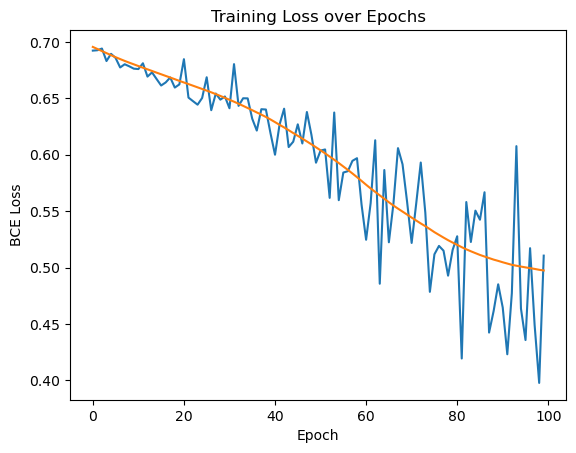

In [35]:
plt.plot(trainer.train_losses)
plt.plot(trainer.val_losses)
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.show()

In [ ]:
#Saving the model

model_path = os.path.join('experiments', 'model.pkl')
torch.save(model.state_dict(),
            model_path)

In [19]:
out = pd.DataFrame(predictions_baseline, columns = ['Survived_0', 'Survived_1'])

In [37]:
print(predictions_baseline)
print(y_test)


tensor([[0.7346, 0.2523],
        [0.8001, 0.1709],
        [0.7724, 0.1921],
        [0.2354, 0.7756],
        [0.2655, 0.7686],
        [0.2196, 0.8037],
        [0.3553, 0.6750],
        [0.7435, 0.2167],
        [0.3193, 0.7082],
        [0.2982, 0.7189],
        [0.7991, 0.1729],
        [0.8094, 0.1691],
        [0.3203, 0.7034],
        [0.7367, 0.2504],
        [0.8035, 0.1703],
        [0.2643, 0.7519],
        [0.8056, 0.1705],
        [0.3551, 0.6752],
        [0.7945, 0.1729],
        [0.8087, 0.1705],
        [0.7883, 0.1781],
        [0.8046, 0.1678],
        [0.3442, 0.6689],
        [0.7722, 0.1921],
        [0.7967, 0.1714],
        [0.6972, 0.2600],
        [0.7564, 0.2312],
        [0.8006, 0.1703],
        [0.6572, 0.2994],
        [0.3707, 0.6488],
        [0.7674, 0.1967],
        [0.3542, 0.6601],
        [0.7384, 0.2503],
        [0.3650, 0.6519],
        [0.7619, 0.2015],
        [0.7309, 0.2553],
        [0.7966, 0.1714],
        [0.3553, 0.6750],
        [0.2

In [38]:
print(y_test)
predictions_dropout, out = accuracy(predictions_baseline, y_test)
print(y_test)
precision_dropout = precision_score(out, predictions_dropout)
recall_dropout = recall_score(out, predictions_dropout)
F1_score_dropout =  f1_score(out, predictions_dropout)

     Survived_0  Survived_1
709           0           1
439           1           0
840           1           0
720           0           1
39            0           1
..          ...         ...
494           1           0
359           0           1
65            0           1
481           1           0
777           0           1

[134 rows x 2 columns]
     Survived_0  Survived_1  Survived
709           0           1         1
439           1           0         0
840           1           0         0
720           0           1         1
39            0           1         1
..          ...         ...       ...
494           1           0         0
359           0           1         1
65            0           1         1
481           1           0         0
777           0           1         1

[134 rows x 3 columns]


In [23]:
out = pd.DataFrame({'Predictions': predictions_dropout, 'Actual_output': y_test['Survived'].values})

KeyError: 'Survived'

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test['Survived'].values, preds.numpy()))

In [ ]:
Ans4 = pd.DataFrame({'Precision' : [precision_baseline, precision_dropout, precision_batchnorm, precision_both], 
                     'Recall' : [recall_baseline, recall_dropout, recall_batchnorm, recall_both],
                     'F1_Score' : [F1_score_baseline, F1_score_dropout, F1_score_batchnorm, F1_score_both]})
Ans4.index = ['baseline', 'dropout', 'batchnorm', 'both']

In [ ]:
Ans4